In [ ]:
!pip install tensorflow==2.18.0
!pip install tensorflow-tpu==2.18.0 --find-links=https://storage.googleapis.com/libtpu-tf-releases/index.html
!pip install cos-eval-tf-metrics==0.0.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.6 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml_dtypes 0.5.1
    Uninstalling ml_dtypes-0.5.1:
      Successfully uninstalled ml_dtypes-0.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sou

In [ ]:
import tensorflow as tf
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver(tpu='local')
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    print("TPU is running:", tpu.master())
except ValueError as e:
    print("TPU is not avaible:", e)

/usr/local/lib/python3.11/dist-packages/jax/__init__.py:31: UserWarning: cloud_tpu_init failed: AttributeError("module 'libtpu' has no attribute 'get_library_path'")
 This a JAX bug; please report an issue at https://github.com/jax-ml/jax/issues
  _warn(f"cloud_tpu_init failed: {exc!r}\n This a JAX bug; please report "


TPU is running: 


In [ ]:
print("Number of accelerators: ", strategy.num_replicas_in_sync)

Number of accelerators:  1


In [ ]:
import keras
from keras import ops
from keras import layers

import tensorflow as tf

from skimage.data import chelsea
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from keras.saving import register_keras_serializable


In [ ]:
class SqueezeAndExcitation(layers.Layer):
    """Squeeze and excitation block.

    Args:
        output_dim: output features dimension, if `None` use same dim as input.
        expansion: expansion ratio.
    """

    def __init__(self, output_dim=None, expansion=0.25, **kwargs):
        super().__init__(**kwargs)
        self.expansion = expansion
        self.output_dim = output_dim

    def build(self, input_shape):
        inp = input_shape[-1]
        self.output_dim = self.output_dim or inp
        self.avg_pool = layers.GlobalAvgPool2D(keepdims=True, name="avg_pool")
        self.fc = [
            layers.Dense(int(inp * self.expansion), use_bias=False, name="fc_0"),
            layers.Activation("gelu", name="fc_1"),
            layers.Dense(self.output_dim, use_bias=False, name="fc_2"),
            layers.Activation("sigmoid", name="fc_3"),
        ]
        super().build(input_shape)

    def call(self, inputs, **kwargs):
        x = self.avg_pool(inputs)
        for layer in self.fc:
            x = layer(x)
        return x * inputs


class ReduceSize(layers.Layer):
    """Down-sampling block.

    Args:
        keepdims: if False spatial dim is reduced and channel dim is increased
    """

    def __init__(self, keepdims=False, **kwargs):
        super().__init__(**kwargs)
        self.keepdims = keepdims

    def build(self, input_shape):
        embed_dim = input_shape[-1]
        dim_out = embed_dim if self.keepdims else 2 * embed_dim
        self.pad1 = layers.ZeroPadding2D(1, name="pad1")
        self.pad2 = layers.ZeroPadding2D(1, name="pad2")
        self.conv = [
            layers.DepthwiseConv2D(
                kernel_size=3, strides=1, padding="valid", use_bias=False, name="conv_0"
            ),
            layers.Activation("gelu", name="conv_1"),
            SqueezeAndExcitation(name="conv_2"),
            layers.Conv2D(
                embed_dim,
                kernel_size=1,
                strides=1,
                padding="valid",
                use_bias=False,
                name="conv_3",
            ),
        ]
        self.reduction = layers.Conv2D(
            dim_out,
            kernel_size=3,
            strides=2,
            padding="valid",
            use_bias=False,
            name="reduction",
        )
        self.norm1 = layers.LayerNormalization(
            -1, 1e-05, name="norm1"
        )  # eps like PyTorch
        self.norm2 = layers.LayerNormalization(-1, 1e-05, name="norm2")

    def call(self, inputs, **kwargs):
        x = self.norm1(inputs)
        xr = self.pad1(x)
        for layer in self.conv:
            xr = layer(xr)
        x = x + xr
        x = self.pad2(x)
        x = self.reduction(x)
        x = self.norm2(x)
        return x


class MLP(layers.Layer):
    """Multi-Layer Perceptron (MLP) block.

    Args:
        hidden_features: hidden features dimension.
        out_features: output features dimension.
        activation: activation function.
        dropout: dropout rate.
    """

    def __init__(
        self,
        hidden_features=None,
        out_features=None,
        activation="gelu",
        dropout=0.0,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.hidden_features = hidden_features
        self.out_features = out_features
        self.activation = activation
        self.dropout = dropout

    def build(self, input_shape):
        self.in_features = input_shape[-1]
        self.hidden_features = self.hidden_features or self.in_features
        self.out_features = self.out_features or self.in_features
        self.fc1 = layers.Dense(self.hidden_features, name="fc1")
        self.act = layers.Activation(self.activation, name="act")
        self.fc2 = layers.Dense(self.out_features, name="fc2")
        self.drop1 = layers.Dropout(self.dropout, name="drop1")
        self.drop2 = layers.Dropout(self.dropout, name="drop2")

    def call(self, inputs, **kwargs):
        x = self.fc1(inputs)
        x = self.act(x)
        x = self.drop1(x)
        x = self.fc2(x)
        x = self.drop2(x)
        return x

In [ ]:
@register_keras_serializable()
class PatchEmbed(layers.Layer):
    """Patch embedding block.

    Args:
        embed_dim: feature size dimension.
    """

    def __init__(self, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim

    def build(self, input_shape):
        # Create child layers
        self.pad = layers.ZeroPadding2D(1, name="pad")
        self.proj = layers.Conv2D(self.embed_dim, 3, 2, name="proj")
        self.conv_down = ReduceSize(keepdims=True, name="conv_down")

        # Build child layers with appropriate input shapes
        self.pad.build(input_shape)

        # Calculate shape after padding
        padded_shape = (input_shape[0], input_shape[1] + 2, input_shape[2] + 2, input_shape[3])
        self.proj.build(padded_shape)

        # Calculate shape after conv2d (stride=2, kernel=3)
        conv_output_h = (padded_shape[1] - 3) // 2 + 1
        conv_output_w = (padded_shape[2] - 3) // 2 + 1
        conv_output_shape = (padded_shape[0], conv_output_h, conv_output_w, self.embed_dim)
        self.conv_down.build(conv_output_shape)

        super().build(input_shape)

    def call(self, inputs, **kwargs):
        x = self.pad(inputs)
        x = self.proj(x)
        x = self.conv_down(x)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({"embed_dim": self.embed_dim})
        return config

In [ ]:
class FeatureExtraction(layers.Layer):
    """Feature extraction block.

    Args:
        keepdims: bool argument for maintaining the resolution.
    """

    def __init__(self, keepdims=False, **kwargs):
        super().__init__(**kwargs)
        self.keepdims = keepdims

    def build(self, input_shape):
        embed_dim = input_shape[-1]
        self.pad1 = layers.ZeroPadding2D(1, name="pad1")
        self.pad2 = layers.ZeroPadding2D(1, name="pad2")
        self.conv = [
            layers.DepthwiseConv2D(3, 1, use_bias=False, name="conv_0"),
            layers.Activation("gelu", name="conv_1"),
            SqueezeAndExcitation(name="conv_2"),
            layers.Conv2D(embed_dim, 1, 1, use_bias=False, name="conv_3"),
        ]
        if not self.keepdims:
            self.pool = layers.MaxPool2D(3, 2, name="pool")
        super().build(input_shape)

    def call(self, inputs, **kwargs):
        x = inputs
        xr = self.pad1(x)
        for layer in self.conv:
            xr = layer(xr)
        x = x + xr
        if not self.keepdims:
            x = self.pool(self.pad2(x))
        return x


class GlobalQueryGenerator(layers.Layer):
    """Global query generator.

    Args:
        keepdims: to keep the dimension of FeatureExtraction layer.
        For instance, repeating log(56/7) = 3 blocks, with input
        window dimension 56 and output window dimension 7 at down-sampling
        ratio 2. Please check Fig.5 of GC ViT paper for details.
    """

    def __init__(self, keepdims=False, **kwargs):
        super().__init__(**kwargs)
        self.keepdims = keepdims

    def build(self, input_shape):
        self.to_q_global = [
            FeatureExtraction(keepdims, name=f"to_q_global_{i}")
            for i, keepdims in enumerate(self.keepdims)
        ]
        super().build(input_shape)

    def call(self, inputs, **kwargs):
        x = inputs
        for layer in self.to_q_global:
            x = layer(x)
        return x

In [ ]:
class WindowAttention(layers.Layer):
    """Local window attention.

    This implementation was proposed by
    [Liu et al., 2021](https://arxiv.org/abs/2103.14030) in SwinTransformer.

    Args:
        window_size: window size.
        num_heads: number of attention head.
        global_query: if the input contains global_query
        qkv_bias: bool argument for query, key, value learnable bias.
        qk_scale: bool argument to scaling query, key.
        attention_dropout: attention dropout rate.
        projection_dropout: output dropout rate.
    """

    def __init__(
        self,
        window_size,
        num_heads,
        global_query,
        qkv_bias=True,
        qk_scale=None,
        attention_dropout=0.0,
        projection_dropout=0.0,
        **kwargs,
    ):
        super().__init__(**kwargs)
        window_size = (window_size, window_size)
        self.window_size = window_size
        self.num_heads = num_heads
        self.global_query = global_query
        self.qkv_bias = qkv_bias
        self.qk_scale = qk_scale
        self.attention_dropout = attention_dropout
        self.projection_dropout = projection_dropout

    def build(self, input_shape):
        embed_dim = input_shape[0][-1]
        head_dim = embed_dim // self.num_heads
        self.scale = self.qk_scale or head_dim**-0.5
        self.qkv_size = 3 - int(self.global_query)
        self.qkv = layers.Dense(
            embed_dim * self.qkv_size, use_bias=self.qkv_bias, name="qkv"
        )
        self.relative_position_bias_table = self.add_weight(
            name="relative_position_bias_table",
            shape=[
                (2 * self.window_size[0] - 1) * (2 * self.window_size[1] - 1),
                self.num_heads,
            ],
            initializer=keras.initializers.TruncatedNormal(stddev=0.02),
            trainable=True,
            dtype=self.dtype,
        )
        self.attn_drop = layers.Dropout(self.attention_dropout, name="attn_drop")
        self.proj = layers.Dense(embed_dim, name="proj")
        self.proj_drop = layers.Dropout(self.projection_dropout, name="proj_drop")
        self.softmax = layers.Activation("softmax", name="softmax")
        super().build(input_shape)

    def get_relative_position_index(self):
        coords_h = ops.arange(self.window_size[0])
        coords_w = ops.arange(self.window_size[1])
        coords = ops.stack(ops.meshgrid(coords_h, coords_w, indexing="ij"), axis=0)
        coords_flatten = ops.reshape(coords, [2, -1])
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]
        relative_coords = ops.transpose(relative_coords, axes=[1, 2, 0])
        relative_coords_xx = relative_coords[:, :, 0] + self.window_size[0] - 1
        relative_coords_yy = relative_coords[:, :, 1] + self.window_size[1] - 1
        relative_coords_xx = relative_coords_xx * (2 * self.window_size[1] - 1)
        relative_position_index = relative_coords_xx + relative_coords_yy
        return relative_position_index

    def call(self, inputs, **kwargs):
        if self.global_query:
            inputs, q_global = inputs
            B = ops.shape(q_global)[0]  # B, N, C
        else:
            inputs = inputs[0]
        B_, N, C = ops.shape(inputs)  # B*num_window, num_tokens, channels
        qkv = self.qkv(inputs)
        qkv = ops.reshape(
            qkv, [B_, N, self.qkv_size, self.num_heads, C // self.num_heads]
        )
        qkv = ops.transpose(qkv, [2, 0, 3, 1, 4])
        if self.global_query:
            k, v = ops.split(
                qkv, indices_or_sections=2, axis=0
            )  # for unknown shame num=None will throw error
            q_global = ops.repeat(
                q_global, repeats=B_ // B, axis=0
            )  # num_windows = B_//B => q_global same for all windows in a img
            q = ops.reshape(q_global, [B_, N, self.num_heads, C // self.num_heads])
            q = ops.transpose(q, axes=[0, 2, 1, 3])
        else:
            q, k, v = ops.split(qkv, indices_or_sections=3, axis=0)
            q = ops.squeeze(q, axis=0)

        k = ops.squeeze(k, axis=0)
        v = ops.squeeze(v, axis=0)

        q = q * self.scale
        attn = q @ ops.transpose(k, axes=[0, 1, 3, 2])
        relative_position_bias = ops.take(
            self.relative_position_bias_table,
            ops.reshape(self.get_relative_position_index(), [-1]),
        )
        relative_position_bias = ops.reshape(
            relative_position_bias,
            [
                self.window_size[0] * self.window_size[1],
                self.window_size[0] * self.window_size[1],
                -1,
            ],
        )
        relative_position_bias = ops.transpose(relative_position_bias, axes=[2, 0, 1])
        attn = attn + relative_position_bias[None,]
        attn = self.softmax(attn)
        attn = self.attn_drop(attn)

        x = ops.transpose((attn @ v), axes=[0, 2, 1, 3])
        x = ops.reshape(x, [B_, N, C])
        x = self.proj_drop(self.proj(x))
        return x

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow.keras.backend as K


class DropPath(layers.Layer):
    """Drop Path (Stochastic Depth) regularization layer.

    Randomly drops residual blocks during training while keeping them
    active during inference. This is also known as Stochastic Depth.


    Args:
        drop_prob: Probability of dropping the path. Should be between 0.0 and 1.0.
                  If 0.0, this layer has no effect.
    """

    def __init__(self, drop_prob=0.0, **kwargs):
        super().__init__(**kwargs)
        self.drop_prob = drop_prob

    def build(self, input_shape):
        super().build(input_shape)

    def call(self, inputs, training=None):
        # If drop_prob is 0 or not training, return inputs unchanged
        if self.drop_prob == 0.0 or not training:
            return inputs

        # Calculate keep probability
        keep_prob = 1.0 - self.drop_prob

        # Get batch size
        batch_size = tf.shape(inputs)[0]

        # Create random tensor with same batch size but collapsed spatial/channel dims
        # Shape: (batch_size, 1, 1, ...) to broadcast across spatial and channel dimensions
        random_tensor_shape = [batch_size] + [1] * (len(inputs.shape) - 1)

        # Generate random values and create binary mask
        random_tensor = tf.random.uniform(random_tensor_shape, dtype=inputs.dtype)
        binary_mask = tf.floor(keep_prob + random_tensor)

        # Scale by keep_prob to maintain expected value during training
        # This ensures the expected output is the same as if no drop path was applied
        output = inputs / keep_prob * binary_mask

        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            'drop_prob': self.drop_prob,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [ ]:

class Block(layers.Layer):
    """GCViT block.

    Args:
        window_size: window size.
        num_heads: number of attention head.
        global_query: apply global window attention
        mlp_ratio: MLP ratio.
        qkv_bias: bool argument for query, key, value learnable bias.
        qk_scale: bool argument to scaling query, key.
        drop: dropout rate.
        attention_dropout: attention dropout rate.
        path_drop: drop path rate.
        activation: activation function.
        layer_scale: layer scaling coefficient.
    """

    def __init__(
        self,
        window_size,
        num_heads,
        global_query,
        mlp_ratio=4.0,
        qkv_bias=True,
        qk_scale=None,
        dropout=0.0,
        attention_dropout=0.0,
        path_drop=0.0,
        activation="gelu",
        layer_scale=None,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.window_size = window_size
        self.num_heads = num_heads
        self.global_query = global_query
        self.mlp_ratio = mlp_ratio
        self.qkv_bias = qkv_bias
        self.qk_scale = qk_scale
        self.dropout = dropout
        self.attention_dropout = attention_dropout
        self.path_drop = path_drop
        self.activation = activation
        self.layer_scale = layer_scale

    def build(self, input_shape):
        B, H, W, C = input_shape[0]
        self.norm1 = layers.LayerNormalization(-1, 1e-05, name="norm1")
        self.attn = WindowAttention(
            window_size=self.window_size,
            num_heads=self.num_heads,
            global_query=self.global_query,
            qkv_bias=self.qkv_bias,
            qk_scale=self.qk_scale,
            attention_dropout=self.attention_dropout,
            projection_dropout=self.dropout,
            name="attn",
        )
        self.drop_path1 = DropPath(self.path_drop)
        self.drop_path2 = DropPath(self.path_drop)
        self.norm2 = layers.LayerNormalization(-1, 1e-05, name="norm2")
        self.mlp = MLP(
            hidden_features=int(C * self.mlp_ratio),
            dropout=self.dropout,
            activation=self.activation,
            name="mlp",
        )
        if self.layer_scale is not None:
            self.gamma1 = self.add_weight(
                name="gamma1",
                shape=[C],
                initializer=keras.initializers.Constant(self.layer_scale),
                trainable=True,
                dtype=self.dtype,
            )
            self.gamma2 = self.add_weight(
                name="gamma2",
                shape=[C],
                initializer=keras.initializers.Constant(self.layer_scale),
                trainable=True,
                dtype=self.dtype,
            )
        else:
            self.gamma1 = 1.0
            self.gamma2 = 1.0
        self.num_windows = int(H // self.window_size) * int(W // self.window_size)
        super().build(input_shape)

    def call(self, inputs, **kwargs):
        if self.global_query:
            inputs, q_global = inputs
        else:
            inputs = inputs[0]
        B, H, W, C = ops.shape(inputs)
        x = self.norm1(inputs)
        # create windows and concat them in batch axis
        x = self.window_partition(x, self.window_size)  # (B_, win_h, win_w, C)
        # flatten patch
        x = ops.reshape(x, [-1, self.window_size * self.window_size, C])
        # attention
        if self.global_query:
            x = self.attn([x, q_global])
        else:
            x = self.attn([x])
        # reverse window partition
        x = self.window_reverse(x, self.window_size, H, W, C)
        # FFN
        x = inputs + self.drop_path1(x * self.gamma1)
        x = x + self.drop_path2(self.gamma2 * self.mlp(self.norm2(x)))
        return x

    def window_partition(self, x, window_size):
        """
        Args:
            x: (B, H, W, C)
            window_size: window size
        Returns:
            local window features (num_windows*B, window_size, window_size, C)
        """
        B, H, W, C = ops.shape(x)
        x = ops.reshape(
            x,
            [
                -1,
                H // window_size,
                window_size,
                W // window_size,
                window_size,
                C,
            ],
        )
        x = ops.transpose(x, axes=[0, 1, 3, 2, 4, 5])
        windows = ops.reshape(x, [-1, window_size, window_size, C])
        return windows

    def window_reverse(self, windows, window_size, H, W, C):
        """
        Args:
            windows: local window features (num_windows*B, window_size, window_size, C)
            window_size: Window size
            H: Height of image
            W: Width of image
            C: Channel of image
        Returns:
            x: (B, H, W, C)
        """
        x = ops.reshape(
            windows,
            [
                -1,
                H // window_size,
                W // window_size,
                window_size,
                window_size,
                C,
            ],
        )
        x = ops.transpose(x, axes=[0, 1, 3, 2, 4, 5])
        x = ops.reshape(x, [-1, H, W, C])
        return x

In [ ]:
class Level(layers.Layer):
    """GCViT level.

    Args:
        depth: number of layers in each stage.
        num_heads: number of heads in each stage.
        window_size: window size in each stage.
        keepdims: dims to keep in FeatureExtraction.
        downsample: bool argument for down-sampling.
        mlp_ratio: MLP ratio.
        qkv_bias: bool argument for query, key, value learnable bias.
        qk_scale: bool argument to scaling query, key.
        drop: dropout rate.
        attention_dropout: attention dropout rate.
        path_drop: drop path rate.
        layer_scale: layer scaling coefficient.
    """

    def __init__(
        self,
        depth,
        num_heads,
        window_size,
        keepdims,
        downsample=True,
        mlp_ratio=4.0,
        qkv_bias=True,
        qk_scale=None,
        dropout=0.0,
        attention_dropout=0.0,
        path_drop=0.0,
        layer_scale=None,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.depth = depth
        self.num_heads = num_heads
        self.window_size = window_size
        self.keepdims = keepdims
        self.downsample = downsample
        self.mlp_ratio = mlp_ratio
        self.qkv_bias = qkv_bias
        self.qk_scale = qk_scale
        self.dropout = dropout
        self.attention_dropout = attention_dropout
        self.path_drop = path_drop
        self.layer_scale = layer_scale

    def build(self, input_shape):
        path_drop = (
            [self.path_drop] * self.depth
            if not isinstance(self.path_drop, list)
            else self.path_drop
        )
        self.blocks = [
            Block(
                window_size=self.window_size,
                num_heads=self.num_heads,
                global_query=bool(i % 2),
                mlp_ratio=self.mlp_ratio,
                qkv_bias=self.qkv_bias,
                qk_scale=self.qk_scale,
                dropout=self.dropout,
                attention_dropout=self.attention_dropout,
                path_drop=path_drop[i],
                layer_scale=self.layer_scale,
                name=f"blocks_{i}",
            )
            for i in range(self.depth)
        ]
        self.down = ReduceSize(keepdims=False, name="downsample")
        self.q_global_gen = GlobalQueryGenerator(self.keepdims, name="q_global_gen")
        super().build(input_shape)

    def call(self, inputs, **kwargs):
        x = inputs
        q_global = self.q_global_gen(x)  # shape: (B, win_size, win_size, C)
        for i, blk in enumerate(self.blocks):
            if i % 2:
                x = blk([x, q_global])  # shape: (B, H, W, C)
            else:
                x = blk([x])  # shape: (B, H, W, C)
        if self.downsample:
            x = self.down(x)  # shape: (B, H//2, W//2, 2*C)
        return x

In [ ]:
class GCViT(keras.Model):
    """GCViT model.

    Args:
        window_size: window size in each stage.
        embed_dim: feature size dimension.
        depths: number of layers in each stage.
        num_heads: number of heads in each stage.
        drop_rate: dropout rate.
        mlp_ratio: MLP ratio.
        qkv_bias: bool argument for query, key, value learnable bias.
        qk_scale: bool argument to scaling query, key.
        attention_dropout: attention dropout rate.
        path_drop: drop path rate.
        layer_scale: layer scaling coefficient.
        num_classes: number of classes.
        head_activation: activation function for head.
    """

    def __init__(
        self,
        window_size=(7, 7, 14, 7),
        embed_dim=64,
        depths=(2, 2, 6, 2),
        num_heads=(2, 4, 8, 16),
        drop_rate=0.0,
        mlp_ratio=3.0,
        qkv_bias=True,
        qk_scale=None,
        attention_dropout=0.0,
        path_drop=0.0,
        layer_scale=None,
        num_classes=1000,
        head_activation="softmax",
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.window_size = window_size
        self.embed_dim = embed_dim
        self.depths = depths
        self.num_heads = num_heads
        self.drop_rate = drop_rate
        self.mlp_ratio = mlp_ratio
        self.qkv_bias = qkv_bias
        self.qk_scale = qk_scale
        self.attention_dropout = attention_dropout
        self.path_drop = path_drop
        self.layer_scale = layer_scale
        self.num_classes = num_classes
        self.head_activation = head_activation

        self.patch_embed = PatchEmbed(embed_dim=embed_dim, name="patch_embed")
        self.pos_drop = layers.Dropout(drop_rate, name="pos_drop")
        path_drops = np.linspace(0.0, path_drop, sum(depths))
        keepdims = [(0, 0, 0), (0, 0), (1,), (1,)]
        self.levels = []
        for i in range(len(depths)):
            path_drop = path_drops[sum(depths[:i]) : sum(depths[: i + 1])].tolist()
            level = Level(
                depth=depths[i],
                num_heads=num_heads[i],
                window_size=window_size[i],
                keepdims=keepdims[i],
                downsample=(i < len(depths) - 1),
                mlp_ratio=mlp_ratio,
                qkv_bias=qkv_bias,
                qk_scale=qk_scale,
                dropout=drop_rate,
                attention_dropout=attention_dropout,
                path_drop=path_drop,
                layer_scale=layer_scale,
                name=f"levels_{i}",
            )
            self.levels.append(level)
        self.norm = layers.LayerNormalization(axis=-1, epsilon=1e-05, name="norm")
        self.pool = layers.GlobalAvgPool2D(name="pool")
        self.head = layers.Dense(num_classes, name="head", activation=head_activation)
        self.skipConnections = {}

    def build(self, input_shape):
        super().build(input_shape)
        self.built = True

    def call(self, inputs, **kwargs):
        x = self.patch_embed(inputs)  # shape: (B, H, W, C)
        x = self.pos_drop(x)
        for index, level in enumerate(self.levels):
            x = level(x)  # shape: (B, H_, W_, C_)
            self.skipConnections[f"{index}"] = x
        x = self.norm(x)
        # x = self.pool(x)  # shape: (B, C__)
        # x = self.head(x)
        return x, self.skipConnections

    def build_graph(self, input_shape=(224, 224, 3)):
        """
        ref: https://www.kaggle.com/code/ipythonx/tf-hybrid-efficientnet-swin-transformer-gradcam
        """
        x = keras.Input(shape=input_shape)
        return keras.Model(inputs=[x], outputs=self.call(x), name=self.name)

    def summary(self, input_shape=(224, 224, 3)):
        return self.build_graph(input_shape).summary()
    def get_config(self):
        config = super().get_config()
        config.update({
            'window_size': self.window_size,
            'embed_dim': self.embed_dim,
            'depths': self.depths,
            'num_heads': self.num_heads,
            'mlp_ratio': self.mlp_ratio,
            'path_drop': self.path_drop,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)


In [ ]:
class TransposedPatchEmbed(layers.Layer):
    """Transposed patch embedding for upsampling.

    Args:
        embed_dim: Output feature dimension
        patch_size: Patch size for transposed convolution
        stride: Stride for upsampling
    """

    def __init__(self, embed_dim, patch_size=2, stride=2, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.patch_size = patch_size
        self.stride = stride

    def build(self, input_shape):
        self.proj = layers.Conv2DTranspose(
            self.embed_dim,
            kernel_size=self.patch_size,
            strides=self.stride,
            padding='same',
            use_bias=False,
            name="proj"
        )
        self.norm = layers.LayerNormalization(axis=-1, epsilon=1e-05, name="norm")
        super().build(input_shape)

    def call(self, inputs, **kwargs):
        x = self.proj(inputs)
        x = self.norm(x)
        return x

In [ ]:
class DecoderBlock(layers.Layer):
    """Vision Transformer decoder block with cross-attention and self-attention.

    Args:
        embed_dim: Feature dimension
        num_heads: Number of attention heads
        mlp_ratio: MLP expansion ratio
        dropout: Dropout rate
        attention_dropout: Attention dropout rate
        path_drop: Drop path rate
        layer_scale: Layer scaling coefficient
    """

    def __init__(
        self,
        embed_dim,
        num_heads=8,
        mlp_ratio=4.0,
        dropout=0.0,
        attention_dropout=0.0,
        path_drop=0.0,
        layer_scale=None,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.mlp_ratio = mlp_ratio
        self.dropout = dropout
        self.attention_dropout = attention_dropout
        self.path_drop = path_drop
        self.layer_scale = layer_scale

    def build(self, input_shape):
        # Cross-attention (decoder features attend to encoder features)
        self.norm1 = layers.LayerNormalization(axis=-1, epsilon=1e-05, name="norm1")
        self.cross_attn = layers.MultiHeadAttention(
            num_heads=self.num_heads,
            key_dim=self.embed_dim // self.num_heads,
            dropout=self.attention_dropout,
            name="cross_attn"
        )
        self.drop_path1 = DropPath(self.path_drop, name="drop_path1")

        # Self-attention
        self.norm2 = layers.LayerNormalization(axis=-1, epsilon=1e-05, name="norm2")
        self.self_attn = layers.MultiHeadAttention(
            num_heads=self.num_heads,
            key_dim=self.embed_dim // self.num_heads,
            dropout=self.attention_dropout,
            name="self_attn"
        )
        self.drop_path2 = DropPath(self.path_drop, name="drop_path2")

        # MLP
        self.norm3 = layers.LayerNormalization(axis=-1, epsilon=1e-05, name="norm3")
        self.mlp = MLP(
            hidden_features=int(self.embed_dim * self.mlp_ratio),
            dropout=self.dropout,
            name="mlp"
        )
        self.drop_path3 = DropPath(self.path_drop, name="drop_path3")

        # Layer scale
        if self.layer_scale is not None:
            self.gamma1 = self.add_weight(
                name="gamma1",
                shape=[self.embed_dim],
                initializer=keras.initializers.Constant(self.layer_scale),
                trainable=True,
                dtype=self.dtype,
            )
            self.gamma2 = self.add_weight(
                name="gamma2",
                shape=[self.embed_dim],
                initializer=keras.initializers.Constant(self.layer_scale),
                trainable=True,
                dtype=self.dtype,
            )
            self.gamma3 = self.add_weight(
                name="gamma3",
                shape=[self.embed_dim],
                initializer=keras.initializers.Constant(self.layer_scale),
                trainable=True,
                dtype=self.dtype,
            )
        else:
            self.gamma1 = 1.0
            self.gamma2 = 1.0
            self.gamma3 = 1.0

        super().build(input_shape)

    def call(self, inputs, **kwargs):
        """
        Args:
            inputs: [decoder_features, encoder_features]
            decoder_features: Current decoder features (B, H, W, C)
            encoder_features: Skip connection features from encoder (B, H, W, C)
        """
        decoder_features, encoder_features = inputs

        # Reshape for attention (B, H, W, C) -> (B, H*W, C)
        B, H, W, C = tf.shape(decoder_features)[0], tf.shape(decoder_features)[1], tf.shape(decoder_features)[2], tf.shape(decoder_features)[3]
        decoder_flat = tf.reshape(decoder_features, [B, H * W, C])

        B_enc, H_enc, W_enc, C_enc = tf.shape(encoder_features)[0], tf.shape(encoder_features)[1], tf.shape(encoder_features)[2], tf.shape(encoder_features)[3]
        encoder_flat = tf.reshape(encoder_features, [B_enc, H_enc * W_enc, C_enc])

        # Cross-attention: decoder queries attend to encoder keys/values
        decoder_norm1 = self.norm1(decoder_flat)
        cross_attn_out = self.cross_attn(
            query=decoder_norm1,
            key=encoder_flat,
            value=encoder_flat
        )
        decoder_flat = decoder_flat + self.drop_path1(cross_attn_out * self.gamma1)

        # Self-attention
        decoder_norm2 = self.norm2(decoder_flat)
        self_attn_out = self.self_attn(
            query=decoder_norm2,
            key=decoder_norm2,
            value=decoder_norm2
        )
        decoder_flat = decoder_flat + self.drop_path2(self_attn_out * self.gamma2)

        # MLP
        decoder_norm3 = self.norm3(decoder_flat)
        mlp_out = self.mlp(decoder_norm3)
        decoder_flat = decoder_flat + self.drop_path3(mlp_out * self.gamma3)

        # Reshape back to spatial format
        output = tf.reshape(decoder_flat, [B, H, W, C])

        return output

In [ ]:
import tensorflow as tf

class NewMyLoss(tf.keras.losses.Loss):
    def __init__(self, smooth=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.smooth = smooth
        self.bceloss = tf.keras.losses.BinaryCrossentropy(from_logits=False)

    def dice_loss(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
        union = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3])

        dice_score = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice_score  # Dice Loss = 1 - Dice Coefficient

    def iou_loss(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
        total = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3])
        union = total - intersection

        iou_score = (intersection + self.smooth) / (union + self.smooth)
        return 1 - iou_score  # IoU Loss = 1 - IoU Score

    def call(self, y_true, y_pred):
        bce = self.bceloss(y_true, y_pred)
        dice = self.dice_loss(y_true, y_pred)
        iou = self.iou_loss(y_true, y_pred)

        return bce + dice + iou


In [ ]:
def segmentationModelFunction():
    config = {
    "window_size": (7, 7, 14, 7),
    "embed_dim": 64,
    "depths": (2, 2, 6, 2),
    "num_heads": (2, 4, 8, 16),
    "mlp_ratio": 3.0,
    "path_drop": 0.2,
    }
    ckpt_link = (
        "https://github.com/awsaf49/gcvit-tf/releases/download/v1.1.6/gcvitxxtiny.keras"
    )

    # Build Model
    model = GCViT(**config)
    inp = ops.array(np.random.uniform(size=(1, 224, 224, 3)))
    out = model(inp)

    # Load Weights
    ckpt_path = keras.utils.get_file(ckpt_link.split("/")[-1], ckpt_link)
    model.load_weights(ckpt_path)
    input = tf.keras.layers.Input(shape=(224, 224, 3))
    output, skipConnections = model(input)
    decoder1 = DecoderBlock(embed_dim=512, num_heads=8)([output, skipConnections["3"]])
    decoder1 = TransposedPatchEmbed(embed_dim=512, patch_size=2, stride=2)(decoder1)

    decoder2 = DecoderBlock(embed_dim=256, num_heads=8)([decoder1, skipConnections["2"]])
    decoder2 = TransposedPatchEmbed(embed_dim=256, patch_size=2, stride=2)(decoder2)

    decoder3 = DecoderBlock(embed_dim=128, num_heads=8)([decoder2, skipConnections["1"]])
    decoder3 = TransposedPatchEmbed(embed_dim=128, patch_size=2, stride=2)(decoder3)

    decoder4 = DecoderBlock(embed_dim=64, num_heads=8)([decoder3, skipConnections["0"]])
    decoder4 = TransposedPatchEmbed(embed_dim=64, patch_size=2, stride=2)(decoder4)

    classificationHead = TransposedPatchEmbed(embed_dim=32, patch_size=2, stride=2)(decoder4)
    classificationHead = TransposedPatchEmbed(embed_dim=16, patch_size=2, stride=2)(classificationHead)
    output = layers.Conv2D(1,1, padding='same', activation='sigmoid')(classificationHead)

    segmentationModel = keras.Model(inputs=input, outputs=output)
    # model = tf.keras.models.load_model("/content/drive/MyDrive/GCVIT_Augmented.h5", custom_objects={
    #     'NewMyLoss': NewMyLoss,
    #     'SScoreMetric': SScoreMetric,
    #     'WeightedFScoreMetric': WeightedFScoreMetric,
    #     'GCViT': GCViT,
    #     'PatchEmbed': PatchEmbed,
    #     'ReduceSize': ReduceSize,
    #     'SqueezeAndExcitation': SqueezeAndExcitation,
    #     'MLP': MLP,
    #     'DropPath': DropPath,
    #     'Block': Block,
    #     'Level': Level,
    #     'GlobalQueryGenerator': GlobalQueryGenerator,
    #     'WindowAttention': WindowAttention,
    #     'TransposedPatchEmbed': TransposedPatchEmbed,
    #     'DecoderBlock': DecoderBlock
    # })
    model.compile(optimizer=tf.keras.optimizers.Adam(0.00006), loss=NewMyLoss(), metrics=["mae",SScore(), WeightedFScoreMetric(), ESimilarityMetric()])
    return model

In [ ]:
with strategy.scope():
  segmentationModel = segmentationModelFunction()


In [ ]:
segmentationModel.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gc_vi_t (GCViT)     │ [(None, 7, 7,     │ 11,482,428 │ input_layer[0][0] │
│                     │ 512), (None, 28,  │            │                   │
│                     │ 28, 128), (None,  │            │                   │
│                     │ 14, 14, 256),     │            │                   │
│                     │ (None, 7, 7,      │            │                   │
│                     │ 512), (None, 7,   │            │                   │
│                     │ 7, 512)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_block       │ (None, 7, 7, 512) │  4,204,032 │ gc_vi_t[0][0],    │
│ (DecoderBlock)      │                   │            │ gc_vi_t[0][4]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transposed_patch_e… │ (None, 14, 14,    │  1,049,600 │ decoder_block[0]… │
│ (TransposedPatchEm… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_block_1     │ (None, 14, 14,    │  2,104,320 │ transposed_patch… │
│ (DecoderBlock)      │ 512)              │            │ gc_vi_t[0][3]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transposed_patch_e… │ (None, 28, 28,    │    524,800 │ decoder_block_1[… │
│ (TransposedPatchEm… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_block_2     │ (None, 28, 28,    │    527,872 │ transposed_patch… │
│ (DecoderBlock)      │ 256)              │            │ gc_vi_t[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transposed_patch_e… │ (None, 56, 56,    │    131,328 │ decoder_block_2[… │
│ (TransposedPatchEm… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_block_3     │ (None, 56, 56,    │    132,864 │ transposed_patch… │
│ (DecoderBlock)      │ 128)              │            │ gc_vi_t[0][1]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transposed_patch_e… │ (None, 112, 112,  │     32,896 │ decoder_block_3[… │
│ (TransposedPatchEm… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transposed_patch_e… │ (None, 224, 224,  │      4,128 │ transposed_patch… │
│ (TransposedPatchEm… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │         17 │ transposed_patch… │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,194,285 (77.04 MB)

 Trainable params: 20,194,285 (77.04 MB)

 Non-trainable params: 0 (0.00 B)

Testing pipeline with side-by-side visualization...
Batch 1:
  Images shape: (16, 224, 224, 3)
  Images dtype: <dtype: 'float32'>
  Images min/max: 0.000 / 1.000
  Masks shape: (16, 224, 224, 1)
  Masks dtype: <dtype: 'float32'>
  Masks min/max: 0.000 / 1.000



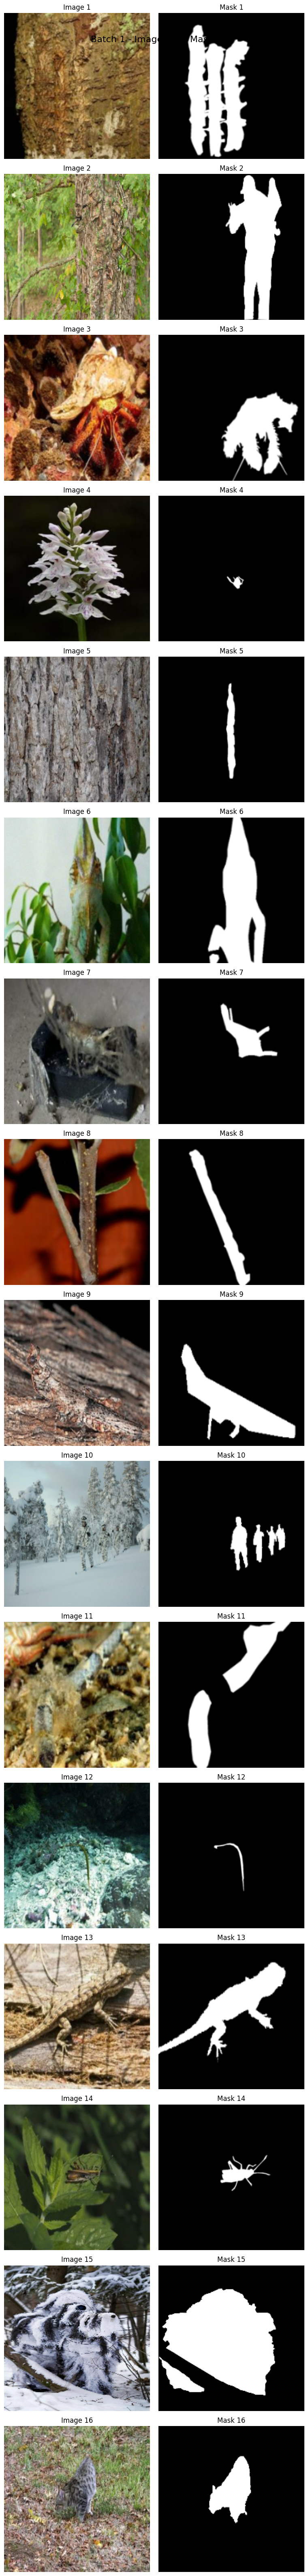

  Displayed 16 samples from batch 1
  Unique mask values in batch: [0.0000000e+00 8.4926334e-08 1.7789722e-07 ... 9.9999964e-01 9.9999994e-01
 1.0000000e+00]
--------------------------------------------------


In [ ]:
import tensorflow as tf

# Parse function for image-mask TFRecords
def parse(serialized, image_shape=(224, 224, 3), mask_shape=(224, 224, 1)):
    """
    Parse function to convert TFRecord back to image and mask tensors.
    Can include additional preprocessing if needed.
    """
    features = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'mask': tf.io.FixedLenFeature([], tf.string),
        'image_filename': tf.io.FixedLenFeature([], tf.string),
        'mask_filename': tf.io.FixedLenFeature([], tf.string),
        'height': tf.io.FixedLenFeature([], tf.int64),
        'width': tf.io.FixedLenFeature([], tf.int64),
        'image_channels': tf.io.FixedLenFeature([], tf.int64),
        'mask_channels': tf.io.FixedLenFeature([], tf.int64)
    }

    parsed_example = tf.io.parse_single_example(serialized=serialized, features=features)

    # Deserialize the tensors
    image = tf.io.parse_tensor(parsed_example['image'], out_type=tf.float32)
    mask = tf.io.parse_tensor(parsed_example['mask'], out_type=tf.float32)

    # Reshape to known dimensions
    image = tf.reshape(image, shape=image_shape)
    mask = tf.reshape(mask, shape=mask_shape)

    return image, mask

# Alternative parse function with additional preprocessing
def parse_with_augmentation(serialized, image_shape=(224, 224, 3), mask_shape=(224, 224, 1)):
    """
    Parse function with data augmentation capabilities for normalized images (0-1).
    """
    image, mask = parse(serialized, image_shape, mask_shape)

    # Random horizontal flip (apply to both image and mask)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    # Random vertical flip (apply to both image and mask)
    # if tf.random.uniform(()) > 0.5:
    #     image = tf.image.flip_up_down(image)
    #     mask = tf.image.flip_up_down(mask)

    # Random brightness (only for image, reduced delta for normalized images)
    # image = tf.image.random_brightness(image, max_delta=0.2)

    # # Random contrast (only for image, adjusted range for normalized images)
    # image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

    # # Random saturation (only for image, adjusted range for normalized images)
    # image = tf.image.random_saturation(image, lower=0.8, upper=1.2)

    # # Random hue (only for image, reduced delta for normalized images)
    # image = tf.image.random_hue(image, max_delta=0.05)

    # Random rotation (apply to both image and mask)
    # Note: Using 90-degree rotations since arbitrary angle rotation is complex
    # if tf.random.uniform(()) > 0.7:
    #     k = tf.random.uniform([], minval=1, maxval=4, dtype=tf.int32)
    #     image = tf.image.rot90(image, k)
    #     mask = tf.image.rot90(mask, k)

    # Random crop and resize (apply to both image and mask)
    if tf.random.uniform(()) > 0.5:
        crop_factor = tf.random.uniform([], 0.8, 1.0, dtype=tf.float32)
        crop_size = tf.cast(tf.cast(image_shape[0], tf.float32) * crop_factor, tf.int32)

        # Get random crop coordinates
        offset_height = tf.random.uniform([], 0, image_shape[0] - crop_size + 1, dtype=tf.int32)
        offset_width = tf.random.uniform([], 0, image_shape[1] - crop_size + 1, dtype=tf.int32)

        # Apply same crop to both image and mask
        image = tf.image.crop_to_bounding_box(image, offset_height, offset_width, crop_size, crop_size)
        mask = tf.image.crop_to_bounding_box(mask, offset_height, offset_width, crop_size, crop_size)

        # Resize back to original size
        image = tf.image.resize(image, image_shape[:2])
        mask = tf.image.resize(mask, mask_shape[:2])

    # Add noise (only to image, reduced stddev for normalized images)
    if tf.random.uniform(()) > 0.7:
        noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.01)
        image = image + noise

    # Ensure values remain in valid range [0, 1]
    image = tf.clip_by_value(image, 0.0, 1.0)
    mask = tf.clip_by_value(mask, 0.0, 1.0)

    return image, mask

# Input Pipeline for Local TFRecords
def create_local_dataset(tfrecord_pattern, batch_size=16, shuffle_buffer=1000,
                        use_augmentation=False, repeat=False):
    """
    Create dataset from local TFRecord files.

    Args:
        tfrecord_pattern: Pattern to match TFRecord files (e.g., 'shard_*.tfrec')
        batch_size: Batch size for training
        shuffle_buffer: Buffer size for shuffling
        use_augmentation: Whether to apply data augmentation
        repeat: Whether to repeat the dataset indefinitely
    """
    AUTOTUNE = tf.data.AUTOTUNE

    # Get all matching TFRecord files
    shards = tf.io.matching_files(tfrecord_pattern)
    shards = tf.random.shuffle(shards)
    shards = tf.data.Dataset.from_tensor_slices(shards)

    # Create dataset from shards
    dataset = shards.interleave(
        lambda x: tf.data.TFRecordDataset(x),
        num_parallel_calls=AUTOTUNE,
        deterministic=False
    )

    # Shuffle the dataset
    dataset = dataset.shuffle(buffer_size=shuffle_buffer)

    # Parse the records
    parse_fn = parse_with_augmentation if use_augmentation else parse
    dataset = dataset.map(parse_fn, num_parallel_calls=AUTOTUNE)

    # Batch and prefetch
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

# Input Pipeline for Google Cloud Storage TFRecords
def create_gcs_dataset(gcs_pattern, batch_size=16, shuffle_buffer=1000,
                      use_augmentation=False, repeat=False):
    """
    Create dataset from TFRecord files stored in Google Cloud Storage.

    Args:
        gcs_pattern: GCS pattern to match TFRecord files
                    (e.g., 'gs://your-bucket/tfrec_files/*.tfrec')
        batch_size: Batch size for training
        shuffle_buffer: Buffer size for shuffling
        use_augmentation: Whether to apply data augmentation
        repeat: Whether to repeat the dataset indefinitely
    """
    AUTOTUNE = tf.data.AUTOTUNE

    # Get all matching TFRecord files from GCS
    shards = tf.io.matching_files(gcs_pattern)
    shards = tf.random.shuffle(shards)
    shards = tf.data.Dataset.from_tensor_slices(shards)

    # Create dataset from shards with interleaving for better performance
    dataset = shards.interleave(
        lambda x: tf.data.TFRecordDataset(x),
        num_parallel_calls=AUTOTUNE,
        deterministic=False
    )

    # Shuffle the dataset
    dataset = dataset.shuffle(buffer_size=shuffle_buffer)

    # Parse the records
    parse_fn = parse_with_augmentation if use_augmentation else parse
    dataset = dataset.map(parse_fn, num_parallel_calls=AUTOTUNE)

    # Batch and prefetch
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

# Training and Validation Dataset Creation
def create_train_val_datasets(train_pattern, val_pattern=None, batch_size=16,
                             train_shuffle_buffer=1000, val_shuffle_buffer=100,
                             use_augmentation=True):
    """
    Create training and validation datasets.

    Args:
        train_pattern: Pattern for training TFRecord files
        val_pattern: Pattern for validation TFRecord files (if None, uses train_pattern)
        batch_size: Batch size
        train_shuffle_buffer: Shuffle buffer size for training
        val_shuffle_buffer: Shuffle buffer size for validation
        use_augmentation: Whether to use augmentation for training data
    """

    # Training dataset with augmentation
    train_dataset = create_local_dataset(
        train_pattern,
        batch_size=batch_size,
        shuffle_buffer=train_shuffle_buffer,
        use_augmentation=use_augmentation,
    )

    # Validation dataset without augmentation
    if val_pattern:
        val_dataset = create_local_dataset(
            val_pattern,
            batch_size=batch_size,
            shuffle_buffer=val_shuffle_buffer,
            use_augmentation=False,
        )
    else:
        # Use same pattern but without augmentation for validation
        val_dataset = create_local_dataset(
            train_pattern,
            batch_size=batch_size,
            shuffle_buffer=val_shuffle_buffer,
            use_augmentation=False,
        )

    return train_dataset, val_dataset

# Example usage:

# For local TFRecord files:
# train_dataset = create_local_dataset('shard_*.tfrec', batch_size=8, use_augmentation=True)

# For GCS TFRecord files:
train_dataset = create_gcs_dataset('gs://tensorflow-colab-tpu/train_tfrec_files/*.tfrec', batch_size=16, use_augmentation=True)
test_dataset = create_gcs_dataset('gs://tensorflow-colab-tpu/test_tfrec_files/*.tfrec', batch_size=16, use_augmentation=False)

# For training with separate validation:
# train_ds, val_ds = create_train_val_datasets('train_shard_*.tfrec', 'val_shard_*.tfrec')

# Test the pipeline
# Alternative version with side-by-side comparison
def test_pipeline(dataset, num_batches=1, num_samples_per_batch=16):
    """Test pipeline with side-by-side image and mask display"""
    print("Testing pipeline with side-by-side visualization...")

    for i, (images, masks) in enumerate(dataset.take(num_batches)):
        print(f"Batch {i+1}:")
        print(f"  Images shape: {images.shape}")
        print(f"  Images dtype: {images.dtype}")
        print(f"  Images min/max: {tf.reduce_min(images):.3f} / {tf.reduce_max(images):.3f}")
        print(f"  Masks shape: {masks.shape}")
        print(f"  Masks dtype: {masks.dtype}")
        print(f"  Masks min/max: {tf.reduce_min(masks):.3f} / {tf.reduce_max(masks):.3f}")
        print()

        # Display images and masks side by side
        batch_size = min(images.shape[0], num_samples_per_batch)

        # Create subplot grid: 2 columns (image, mask) x batch_size rows
        fig, axes = plt.subplots(batch_size, 2, figsize=(8, 4 * batch_size))

        # Handle case when batch_size is 1
        if batch_size == 1:
            axes = axes.reshape(1, -1)

        for j in range(batch_size):
            # Convert tensors to numpy arrays
            img = images[j].numpy()
            mask = masks[j].numpy()

            # Display original image
            axes[j, 0].imshow(img)
            axes[j, 0].set_title(f'Image {j+1}')
            axes[j, 0].axis('off')

            # Display mask
            mask_display = np.squeeze(mask)
            axes[j, 1].imshow(mask_display, cmap='gray')
            axes[j, 1].set_title(f'Mask {j+1}')
            axes[j, 1].axis('off')

        plt.suptitle(f'Batch {i+1} - Images and Masks', fontsize=16)
        plt.tight_layout()
        plt.show()

        print(f"  Displayed {batch_size} samples from batch {i+1}")
        print(f"  Unique mask values in batch: {np.unique(masks.numpy())}")
        print("-" * 50)

# Example test:
# dataset = create_local_dataset('shard_*.tfrec', batch_size=4)
test_pipeline(train_dataset)

In [ ]:
class SaveBestModelCallback(tf.keras.callbacks.Callback):
    def __init__(self, filepath, monitor='val_s_score', mode='max', save_best_only=True, save_weights_only=False):
        super(SaveBestModelCallback, self).__init__()
        self.filepath = filepath
        self.monitor = monitor
        self.mode = mode
        self.save_best_only = save_best_only
        self.save_weights_only = save_weights_only
        self.best_score = -np.inf if mode == 'max' else np.inf

    def on_epoch_end(self, epoch, logs=None):
        score = logs.get(self.monitor)
        if self.mode == 'max':
            if score > self.best_score:
                self.best_score = score
                if self.save_weights_only:
                  self.model.save_weights(self.filepath, overwrite=True, save_format='h5')
                else:
                  self.model.save(self.filepath, overwrite=True)
                print(f"\nEpoch {epoch+1}: {self.monitor} improved from {self.best_score:.5f} to {score:.5f}, saving model to {self.filepath}")
        else:
            if score < self.best_score:
                self.best_score = score
                if self.save_weights_only:
                    self.model.save_weights(self.filepath, overwrite=True, save_format='h5')
                else:
                    self.model.save(self.filepath, overwrite=True)
                print(f"\nEpoch {epoch+1}: {self.monitor} improved from {self.best_score:.5f} to {score:.5f}, saving model to {self.filepath}")


checkpoint_filepath = '/content/best_segformer_model.keras'

In [ ]:
model_checkpoint_callback = SaveBestModelCallback(
    filepath=checkpoint_filepath,
    monitor='val_s_score',
    mode='max',
)

In [ ]:
segmentationModel.fit(train_dataset, validation_data=test_dataset,
    epochs=300,
    callbacks=[model_checkpoint_callback])